In [ ]:
import pickle
import numpy as np
from pathlib import Path
from tqdm import tqdm
from vebir.interference_models.pca import loo_pca, malinowski_ind, pca
from vebir.absorbance_estimators.ebs import EBS
from vebir.absorbance_estimators.solvers import map_als, map_pb, pb_loss, als_loss
from vebir.absorbance_estimators.veb import VEB, norm_cdf, norm_pdf
from vebir.utils.metrics import compute_correlation_metrics, correlation_metrics_to_df
import pandas as pd 
from vebir.utils.distribute import distribute_veb

import matplotlib.pyplot as plt
import multiprocessing as mp
from scipy.optimize import minimize
import cvxpy as cp

from scipy.linalg import svd
from scipy.stats import norm

def bootstrap_sample(Z):
    idx = np.random.choice(Z.shape[0], size=Z.shape[0], replace=True)
    return Z[idx]

def pca_bootstrap(y, Z, tau, sigma, c, B=100, loss = "PB",verbose=False):
    
    boot_x = []
    boot_a = []
    mod = VEB(c=c, loss = loss)
    
    for b in range(B):
        Zb = bootstrap_sample(Z)
        mub, _, _, Wb = pca(Zb)
        Wb = Wb[:,:c]
        
        mod.tau = tau
        mod.sigma_hat = sigma
        
        mod.map(y,mub,Wb)

        boot_x.append(mod.x)
        boot_a.append(y-mod.interference)
        
    boot_x = np.array(boot_x)
    boot_a = np.array(boot_a)
        
    return boot_x, boot_a

In [11]:
REPO_ROOT = Path.cwd().resolve().parent
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"

GT_DIR = REPO_ROOT / "data" / "spectrabase" / "teflon"
LAB_DIR = REPO_ROOT / "data" / "raw" / "teflon" / "laboratory_samples"
PREPROC_DIR = REPO_ROOT / "data" / "preprocessed" / "teflon"
CORRECTIONS_DIR = REPO_ROOT / "data" / "corrections" / "teflon" / "veb" / "pb"

with open(PREPROC_DIR / "raw_spectra_dict.pkl", "rb") as f:
    raw_spectra_dict = pickle.load(f)
    
with open(PREPROC_DIR / "blanks_dict.pkl", "rb") as f:
    blanks_dict = pickle.load(f)
    
with open(CORRECTIONS_DIR / "sigma_tau.pkl", "rb") as f:
    veb_pb_dict = pickle.load(f)
    
blanks_id = blanks_dict["2011"].copy().index.tolist()
Z = np.array(blanks_dict["2011"])   
chat_cv = loo_pca(Z)[1]
mu, _, _, W = pca(Z)
W = W[:,:chat_cv]

wn = np.sort(pd.read_csv(LAB_DIR / "zerofilling.txt", header=None).iloc[:, 0])

In [19]:
boot_dict = {}
for comp in ["12-Tricosanone","Ammonium sulfate","Suberic Acid","levoglucosan"]:
    boot_dict[comp] = veb_pb_dict[comp]

In [ ]:
alpha = 0.01
for comp in boot_dict.keys():
    for correction in boot_dict[comp]:
        sample_id,tau,sigma = correction["sample_id"], correction["tau"], correction["sigma_hat"]
        y = np.array(raw_spectra_dict[comp]["raw"].loc[sample_id])
        boot_x, boot_a, LOD = pca_bootstrap(y, Z, tau, sigma, c = chat_cv, B=100, loss = "PB",verbose=False)
        
        correction["boot_x"] = boot_x
        correction["boot_a"] = boot_a
        
        r = correction["absorbance"] - boot_a
        stdev = np.std(boot_a, axis=0)
        crit = np.quantile(np.max(r/stdev,axis=0), 1-alpha)
        
        correction["LOD"] = crit*stdev

KeyboardInterrupt: 

In [172]:
with open("boot_dict.pkl", "wb") as f:
    pickle.dump(boot_dict, f)

In [ ]:
for comp in boot_dict.keys():
    for correction in boot_dict[comp]:
        boot_a = correction["boot_a"]
        a = correction["absorbance"]
        
        r = correction["absorbance"] - boot_a
        stdev = np.std(boot_a, axis=0)
        crit = np.quantile(np.max(r/stdev,axis=0), 0.99)
        
        correction["LOD"] = crit*stdev

In [173]:
with open("boot_dict.pkl", "rb") as f:
    boot_dict = pickle.load(f)

In [174]:
comp = "levoglucosan"

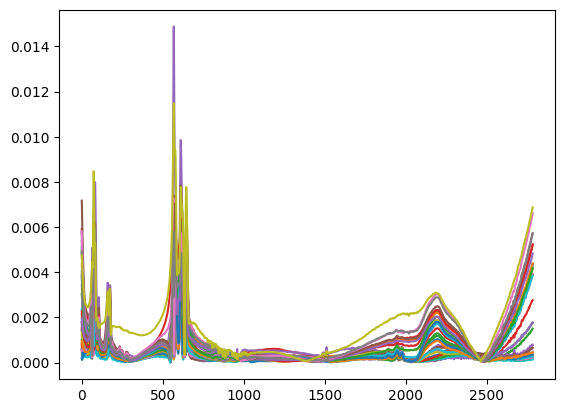

In [175]:
LOD = []
for correction in boot_dict[comp]:
    plt.plot(correction["LOD"])
    LOD.append(correction["LOD"])